# cheesypy tutorial

`cheesypy` is the Python client for the [Cheesemonger](https://github.com/broadinstitute/cheesemonger) perturb-seq API.
It talks to a Cheesemonger server over HTTP and returns results as **pandas** objects, so you can go from a query to a plot in one line.

This notebook walks through:
1. Connecting to a server
2. Exploring datasets & metadata
3. Every query pattern (series, multi-datatype, aggregation, count, cross-screen, multi-screen, diagonal)
4. Plotting (a volcano plot)

> Run order matters only for the connection cell; the query cells are independent.

In [1]:
!uv pip install cheesypy --extra-index-url https://us-central1-python.pkg.dev/cds-artifacts/public-python/simple/

Using Python 3.12.13 environment at: /Users/naquib/GitHub/cheesemonger/.venv
Checked 1 package in 5ms


In [12]:
!uv pip install matplotlib

Using Python 3.12.13 environment at: /Users/naquib/GitHub/cheesemonger/.venv
Resolved 11 packages in 1.01s                                        
⠙ Preparing packages... (0/7)                                                   
⠙ Preparing packages... (0/7)-------------------     0 B/119.90 KiB          
⠙ Preparing packages... (0/7)------------------- 16.00 KiB/119.90 KiB        
⠙ Preparing packages... (0/7)------------------- 32.00 KiB/119.90 KiB        
⠙ Preparing packages... (0/7)m------------------ 48.00 KiB/119.90 KiB        
⠙ Preparing packages... (0/7)--------------- 60.22 KiB/119.90 KiB        
⠙ Preparing packages... (0/7)----------- 76.22 KiB/119.90 KiB        
⠙ Preparing packages... (0/7)---------- 92.22 KiB/119.90 KiB        
⠙ Preparing packages... (0/7)---------- 108.22 KiB/119.90 KiB       
⠙ Preparing packages... (0/7)---------- 108.22 KiB/119.90 KiB       
cycler               ------------------------------     0 B/8.13 KiB
⠙ Preparing packages... (0/7)---------- 

In [ ]:
import httpx

from cheesypy import Cheesemonger

BASE_URL = "https://dev.cds.team/cheesemonger"

cm = Cheesemonger(BASE_URL, _client=httpx.Client(base_url=BASE_URL, auth=("REPLACE_USERNAME", "REPLACE_PASSWORD"), timeout=600))


## 2. Explore

`list_datasets()` and `metadata()` tell you what's available — dimensions, their labels, the loaded blocks (screens), and the datatypes.

In [6]:
cm.list_datasets()   # -> DataFrame: name, blocks, datatypes

,name,blocks,datatypes
0,perturb-scuba,1,14


In [7]:
meta = cm.metadata("perturb-scuba")
print("last_dimension:", meta["last_dimension"])
print("dimensions:", [(d["name"], d["size"]) for d in meta["dimensions"]])
print("blocks:", [b["name"] for b in meta["blocks"]])
print("datatypes:", [d["name"] for d in meta["datatypes"]])

last_dimension: screen
dimensions: [('Timepoint', 2), ('Response', 14588), ('Target', 2)]
blocks: ['PS-SC-1']
datatypes: ['CtrlPseudobulk', 'nCtrlCells', 'STD', 'FDR', 'PermutationP', 'L2FC', 'DetrendedMeanDifference', 'MeanDifference', 'ZScore', 'nNonzeroCtrlCells', 'nNonzeroTargetCells', 'TargetPseudobulk', 'nPermutations', 'nTargetCells']


## 3. Concepts in one line

A query **fixes** some dimensions (as keyword args) and returns the ones left free.

- The **block key** (here `screen`) selects one screen; include it to target a block, omit it to span all blocks.
- Fix all but one dimension → a vector (`Series`); fix all → a scalar.
- The PESCA dims are `Timepoint` (e.g. `"D4"`, `"D7"`), `Target` (perturbed gene, entrez ID), `Response` (measured gene, entrez ID).

## 4. Series query — one perturbation, all response genes

Fix screen + timepoint + target; get the ZScore across every response gene. Returns a `pd.Series` indexed by `Response`.

In [8]:
z = cm.series("perturb-scuba", "ZScore",
              screen="PS-SC-1", Timepoint="D4", Target="23293")
print(type(z), z.shape, "| index:", z.index.name)
z.head()

<class 'pandas.Series'> (14588,) | index: Response


Response
10      -0.634196
100     -0.919917
10000   -2.592765
10001   -0.141573
10002         NaN
Name: ZScore, dtype: float64

## 5. Several datatypes at once (volcano data)

Pass a list of datatypes at the same coordinates → a `pd.DataFrame` (rows = response genes, columns = datatypes). This is the one-call way to get everything a volcano plot needs.

In [9]:
df = cm.series("perturb-scuba", ["L2FC", "FDR", "ZScore"],
               screen="PS-SC-1", Timepoint="D4", Target="23293")
df.head()

datatype,L2FC,FDR,ZScore
Response,,,
10,-0.004180,0.817551,-0.634196
100,-0.063886,0.737323,-0.919917
10000,-0.103139,0.137135,-2.592765
10001,-0.003405,0.934139,-0.141573
10002,NaN,NaN,NaN


Matplotlib is building the font cache; this may take a moment.


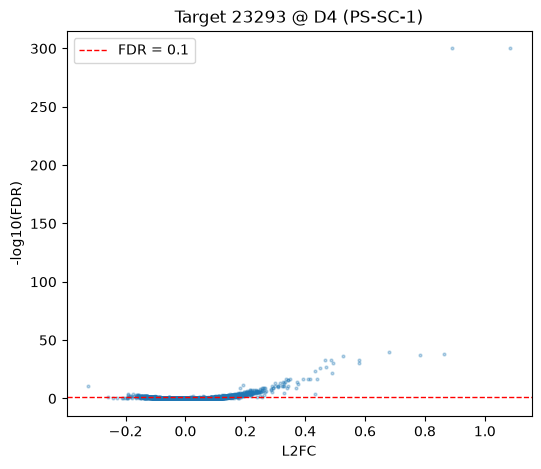

In [13]:
# Volcano plot: L2FC vs -log10(FDR), computed client-side with pandas
import numpy as np
import matplotlib.pyplot as plt

df = df.dropna(subset=["L2FC", "FDR"])
y = -np.log10(df["FDR"].clip(lower=1e-300))

plt.figure(figsize=(6, 5))
plt.scatter(df["L2FC"], y, s=4, alpha=0.3)
plt.axhline(-np.log10(0.1), color="red", ls="--", lw=1, label="FDR = 0.1")
plt.xlabel("L2FC"); plt.ylabel("-log10(FDR)")
plt.title("Target 23293 @ D4 (PS-SC-1)"); plt.legend(); plt.show()

## 6. Aggregation within a screen

Collapse a dimension with `aggregate(...)`. `how="mean"` over `Target` gives the mean ZScore across all targets, one value per response gene.

In [14]:
mean_z = cm.aggregate("perturb-scuba", "ZScore",
                      over="Target", how="mean",
                      screen="PS-SC-1", Timepoint="D4")
print(mean_z.shape, "| index:", mean_z.index.name)
mean_z.head()

(14588,) | index: Response


Response
10      -0.621085
100     -0.744326
10000   -1.443740
10001   -0.355154
10002         NaN
Name: ZScore, dtype: float64

## 7. Count significant hits

`how="count_lt"` counts values below a threshold. Counting `FDR < 0.1` over `Response` gives, per target, how many response genes were significant.

In [15]:
hits = cm.aggregate("perturb-scuba", "FDR",
                    over="Response", how="count_lt", threshold=0.1,
                    screen="PS-SC-1", Timepoint="D4")
hits   # Series indexed by Target

Target
23293    718
55149     12
Name: FDR, dtype: int64

## 8. Across screens

Two cross-screen patterns (these need **more than one** screen loaded):

- **Aggregate over screen** — collapse the screens into one vector (`over="screen"`).
- **Span screens without aggregating** — omit the block key; get a `DataFrame` (screen × response gene) to compare them side by side.

In [ ]:
# Mean ZScore across all screens for one target at D4 (one value per response gene)
across = cm.aggregate("perturb-scuba", "ZScore",
                      over="screen", how="mean",
                      Timepoint="D4", Target="23293")
across.head()

In [ ]:
# Compare the same vector across screens (omit `screen`). With >1 screen this is a DataFrame.
per_screen = cm.series("perturb-scuba", "ZScore", Timepoint="D4", Target="23293")
per_screen.head()

## 9. Diagonal (self-targeting)

The diagonal pulls values where two dimensions share a coordinate label — e.g. the response of a gene to *its own* knockout. Returns a `Series` indexed by the shared label.

In [16]:
self_effect = cm.diagonal("perturb-scuba", "L2FC",
                          dims=("Target", "Response"),
                          screen="PS-SC-1", Timepoint="D4")
self_effect

label
23293   -0.326335
55149   -0.320831
Name: L2FC, dtype: float64

## 10. Raw responses & full control

Pass `raw=True` to any read to get the plain response dict instead of pandas. Or use the low-level `query(...)`, which mirrors the API exactly.

In [17]:
raw = cm.series("perturb-scuba", "ZScore",
                screen="PS-SC-1", Timepoint="D4", Target="23293", raw=True)
print(raw.keys())
print("shape:", raw["shape"], "| index dims:", [lvl["dimension"] for lvl in raw["index"]])

dict_keys(['blocks', 'aggregation', 'shape', 'index', 'data'])
shape: [14588] | index dims: ['Response']


In [19]:
# Equivalent low-level call
out = cm.query(
    "perturb-scuba", "ZScore",
    select={"screen": "PS-SC-1", "Timepoint": "D4"},
    aggregate={"type": "mean", "over": "Target"},
)
out.head()

Response
10      -0.621085
100     -0.744326
10000   -1.443740
10001   -0.355154
10002         NaN
Name: ZScore, dtype: float64

## Return-type cheat sheet

| free dims | datatypes | result |
| --------- | --------- | ------ |
| 0 | 1 | scalar |
| 0 | N | `Series` (indexed by datatype) |
| 1 | 1 | `Series` |
| 1 | N | `DataFrame` (cols = datatypes) |
| 2 | 1 | `DataFrame` |
| 2 | N | `dict[datatype -> DataFrame]` |

See [clients/cheesypy/README.md](../README.md) for the full reference.